**This notebook presents a simple example of the `umbra` transit search code version 1.0.0.**

In [1]:
import numpy as np

import umbra
import batman

%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
RNG = np.random.default_rng(5627323756)
MIN_IN_DAY = 24 * 60

We start by defining observational parameters and setting up a hot Jupiter type system for the batman transit model.

In [3]:
# Observational parameters.
baseline = 90  # The star was observed for 90 days.
exp_time = 3./MIN_IN_DAY  # We took 3 minute exposures...
exp_cadence = 5./MIN_IN_DAY  # ...and an exposure every 5 minutes
start_time = 100. # Observations started at day 100.
white_noise = 500e-6  # White noise had a standard deviation of 500 ppm.

# Transit parameters.
ld_type = 'linear'
ld_pars = [0.6,]

period = 5.876
impact = 0.3

# Compute the scaled semi-major axis and the inclination.
sma = umbra.get_sm_axis_kepler(1.41, period)  # Assume solar density.
inc = umbra.get_orbital_inclination(impact, sma, 0., 90.)

# Intialize the TransitParams object.
params = batman.TransitParams()
params.t0 = 3.
params.per = period
params.rp = 0.02
params.a = sma
params.inc = inc
params.ecc = 0.                     
params.w = 90.                        
params.limb_dark = ld_type
params.u = ld_pars

Next we generate a lightcurve with the transit and white noise.

In [4]:
# Generate the observation times.
npoints = int(baseline / exp_cadence)  # 5 minute cadence
time = start_time + exp_cadence * np.arange(npoints)

# Evaluate the transit model.
m = batman.TransitModel(params, time, exp_time=exp_time, supersample_factor=9)
transit = m.light_curve(params)

# Generate the white noise.
noise = RNG.normal(loc=0, scale=white_noise, size=npoints)

# Compute the final flux and corresponding error values.
flux = transit + noise
flux_err = white_noise * np.ones_like(flux)

Let's inspect the lightcurve.

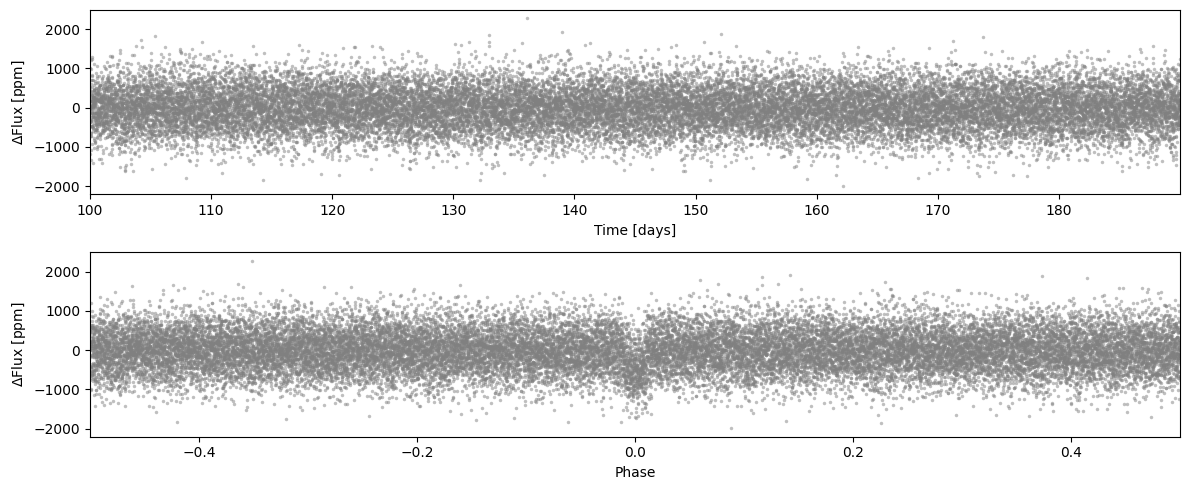

In [5]:
# Compute the folded-phase, centering the transit at phase zero.
phase = umbra.phase_fold(time, params.per, params.t0)

# Plot the lightcurve as a function of time and phase.
plt.figure(figsize=(12, 5))

ax = plt.subplot(211)

plt.plot(time, 1e6 * (flux - 1), '.', markersize=5, markeredgecolor='None', alpha=0.5, color='gray')
plt.xlim(time[0], time[-1])

plt.xlabel('Time [days]')
plt.ylabel(r'$\Delta$Flux [ppm]')

plt.subplot(212, sharey=ax)

plt.plot(phase, 1e6 * (flux - 1), '.', markersize=5, markeredgecolor='None', alpha=0.5, color='gray')
plt.xlim(-0.5, 0.5)

plt.xlabel('Phase')
plt.ylabel(r'$\Delta$Flux [ppm]')

plt.tight_layout()

We're now ready to perform the transit search. We start by creating in instance of the TransitSearch class and setting the perioogram normalisation and the spacing of the duration grid. All target independent parameters of the search are set here.

In [6]:
ts = umbra.TransitSearch(
    normalisation='umbra',  # Use the 'umbra' normalisation for the periodogram power.
    frac_duration_step=1.1,  # Set the duration sampling.
)

Next we perform a transit least-squares (TLS) search. All target specific parameters are set here.

In [7]:
search_result = ts.transit_lstsq(
    time,  # The lightcurve.
    flux,
    flux_err,
    exp_time,  # The observational parameters.
    exp_cadence,
    min_stellar_radius=0.8,  # A range of stellar parameters around the true solar values.
    max_stellar_radius=1.2,
    min_stellar_mass=0.8,
    max_stellar_mass=1.2,
    ld_type=ld_type,  # We use the true limb-darkening for this example search.
    ld_pars=ld_pars,
    output_file='simple-example.asdf'
)

The returned result is an asdf file tree. Since we provided a value for output_file this asdf file has also been written to disk. Let's take a look at the contents of the file with the asdf `info` method.

In [8]:
search_result.info(max_rows=None)

root (AsdfObject)
├─config (dict)
│ ├─global (dict)
│ │ ├─version (str): 0.7.1
│ │ ├─min_transits (int): 3
│ │ ├─min_separation (float): 3.0
│ │ ├─period_sampling (int): 3
│ │ ├─min_period (NoneType): None
│ │ ├─max_period (NoneType): None
│ │ ├─epoch_sampling (int): 20
│ │ ├─min_epoch_step (float): 0.0006944444444444445
│ │ ├─max_epoch_step (float): 0.003472222222222222
│ │ ├─circular_orbits (bool): True
│ │ ├─frac_duration_step (float): 1.1
│ │ ├─period_group_sampling (int): 3
│ │ ├─normalisation (str): umbra
│ │ └─num_processes (NoneType): None
│ └─target (dict)
│   ├─templates (str): TLS
│   ├─exp_time (float): 0.0020833333333333333
│   ├─exp_cadence (float): 0.003472222222222222
│   ├─min_stellar_radius (float): 0.8
│   ├─max_stellar_radius (float): 1.2
│   ├─min_stellar_mass (float): 0.8
│   ├─max_stellar_mass (float): 1.2
│   ├─ld_type (str): linear
│   └─ld_pars (ndarray)
│     ├─shape (tuple)
│     │ └─[0] (int): 1
│     └─dtype (Float64DType): float64
└─search (dict)
  ├─head

The file consist of two main parts *config*, which contains all input parameters to umbra, and *search* which contains the search results. *config* further consists of *global*, the parameters passed when initilizaing the `TransitSearch` class, and *target* the parameters passed to the `transit_lstsq` call. *search* is divided into the *header*, which contains the period and duration grid, as well as information on the period groups used. Finally, *circular* contains the returned *periodogram*, and the best-fit *transit_model*. For further examples see the other notebooks.

Finally we plot the search result. In the top panel we show the periodogram power which is defined to be normalised between 0 and 1. The middle panel shows the $\Delta\chi^2_{-}$ and $\Delta\chi^2_{+}$ corresponding to the peak power. The $\Delta\chi^2_{-}$ is the best-fit improvement corresponding to the peak power. The $\Delta\chi^2_{+}$ corresponds to the best-fit unphysical (i.e. corresponding to a brightening) transit model at the same period and duration as the peak power. Finally the bottom panel shows the lightcurve phase-folded to the recovered period and epoch, together with the transit template used in the detection.

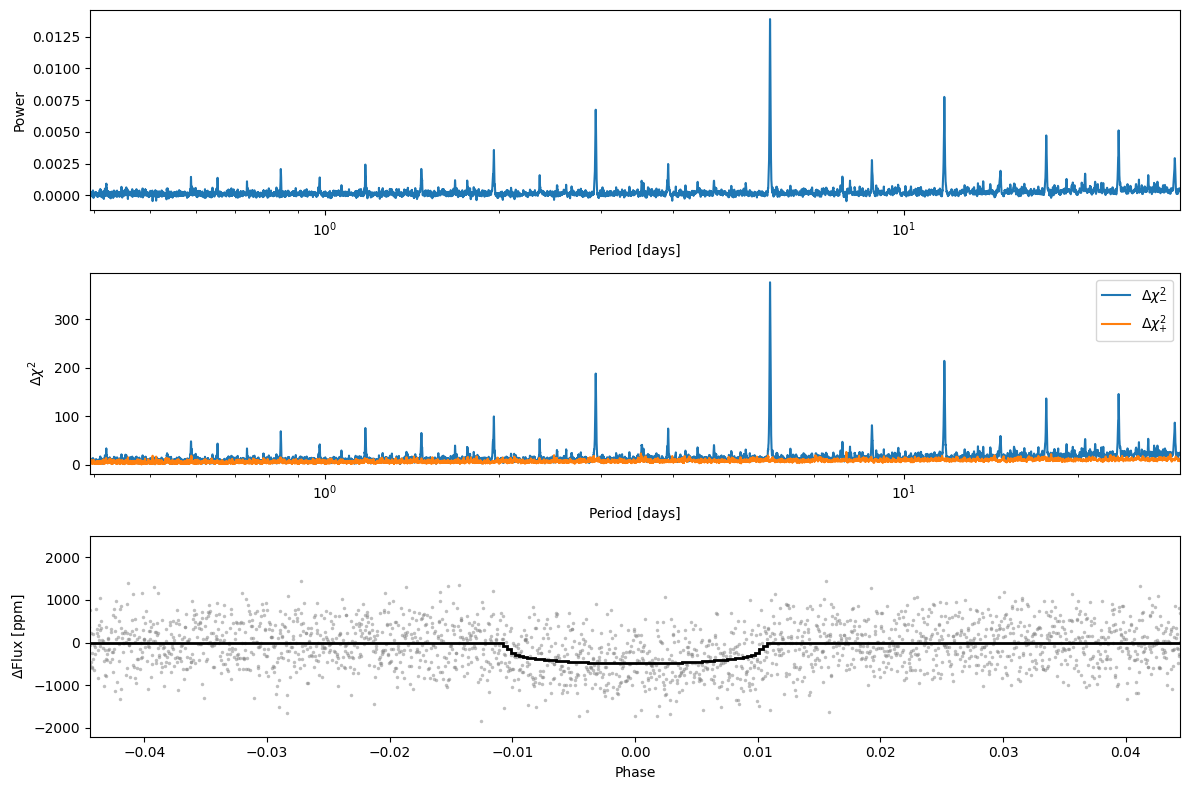

In [9]:
# Unpack parts of the tree.
periodogram = search_result['search']['circular']['periodogram']  # Search result periodogram.
transit_model = search_result['search']['circular']['transit_model']  # Best-fit transit model.

plt.figure(figsize=(12, 8))
    
ax = plt.subplot(311)

plt.semilogx(periodogram['periods'], periodogram['power'])

plt.xlim(periodogram['periods'][0], periodogram['periods'][-1])

plt.xlabel('Period [days]')
plt.ylabel('Power')

plt.subplot(312, sharex=ax)

plt.semilogx(periodogram['periods'], periodogram['dchisq_dec'], label=r'$\Delta\chi^2_{-}$')
plt.semilogx(periodogram['periods'], periodogram['dchisq_inc'], label=r'$\Delta\chi^2_{+}$')

plt.legend()
plt.xlabel('Period [days]')
plt.ylabel(r'$\Delta\chi^2$')

plt.subplot(313)

# Phase fold the lightcurve to the parameters of the best-fit model.
parameters = transit_model['parameters']
phase = umbra.phase_fold(time, parameters['period'], parameters['midpoint'])

plt.plot(phase, 1e6 * (flux - 1), '.', markersize=5, markeredgecolor='None', alpha=0.5, color='gray')
plt.stairs(1e6 * (transit_model['flux'] - 1), transit_model['phase_edges'], baseline=None, lw=2, color='k', zorder=10)

dx = 2*parameters['duration']/parameters['period']
plt.xlim(-dx, dx)

plt.xlabel('Phase')
plt.ylabel(r'$\Delta$Flux [ppm]')

plt.tight_layout()